In [1]:
with open("data/all_rasp_canonical_preds.txt") as fh:
    data = fh.readlines()

data = [d.split(", ") for d in data]

In [3]:
datasets = set([d[0] for d in data])

In [4]:
datasets

{'HIV', 'ara-tha', 'covid', 'ecoli', 'human'}

In [5]:
import data_utils as du

species_in_order = ["ara-tha", "covid", "ecoli", "HIV", "human"]
pretty_map = {
    "ara-that": "Arabidopsis",
    "codid": "COVID",
    "ecoli": "E. Coli",
    "HIV": "HIV",
    "human": "Human"
}

ds_model_map = {}
for ds in species_in_order:
    ds_model_map[ds] = {}
    for m in du.models:
        ds_model_map[ds][m] = []

In [7]:
for d in data:
    ds = d[0]
    model = d[2]
    acc = float(d[5])
    ds_model_map[ds][model].append(acc)

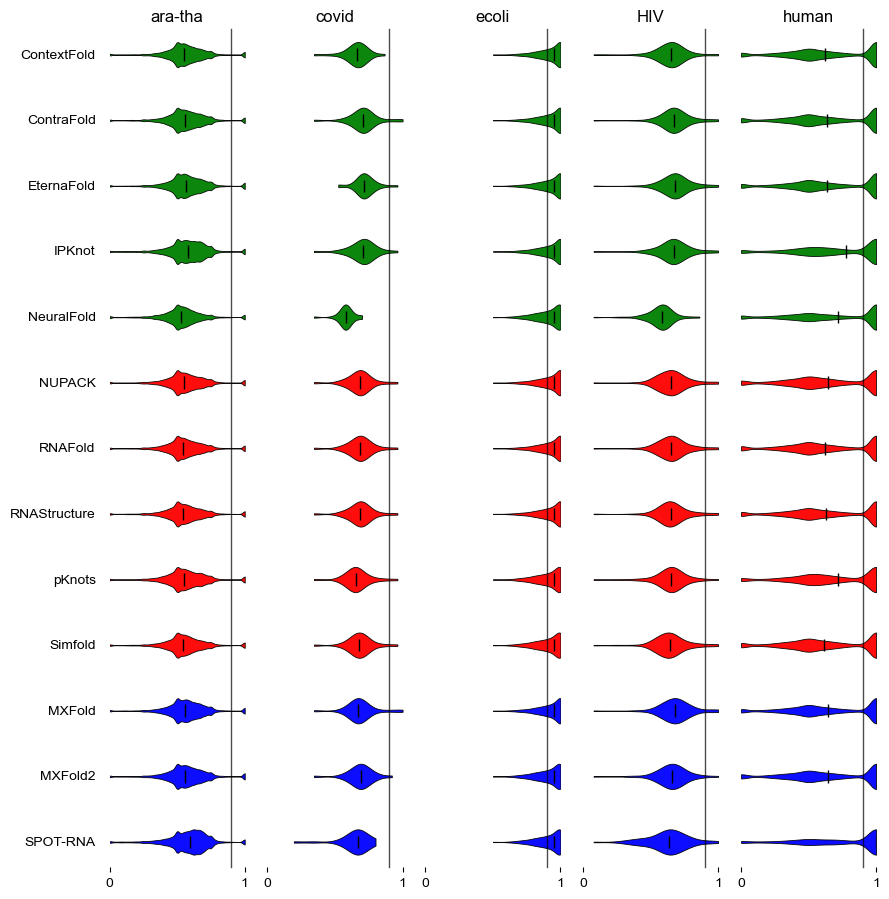

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


model_order = [
    "ContextFold", "ContraFold", "EternaFold", "IPKnot", "NeuralFold",
    "NUPACK", "RNAFold", "RNAStructure", "pKnots", "Simfold",
    "MXFold", "MXFold2", "SPOT-RNA"
]

n_rows = len(model_order)
n_cols = len(species_in_order)

fig_w = max(1.8 * n_cols, 8)
fig_h = max(0.7 * n_rows, 8)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(fig_w, fig_h),
    squeeze=False,
    sharex=False,
    sharey=False
)

for row_idx, model in enumerate(model_order):
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = 'Arial'
    for col_idx, dataset in enumerate(species_in_order):
        ax = axes[row_idx, col_idx]

        values = ds_model_map.get(dataset, {}).get(model, [])
        values = [v for v in values if v is not None and not np.isnan(v)]

        violin = ax.violinplot(
            values,
            positions=[0],
            widths=0.8,
            showmeans=False,
            showmedians=True,
            showextrema=False,
            vert=False
        )

        model_color = du.get_model_color(model)

        for body in violin["bodies"]:
            body.set_facecolor(model_color)
            body.set_edgecolor("black")
            body.set_alpha(0.95)
            body.set_linewidth(0.6)

        if "cmedians" in violin:
            violin["cmedians"].set_color("black")
            violin["cmedians"].set_linewidth(1.0)


        ax.set_xlim(0.0, 1.0)
        ax.set_ylim(-0.8, 0.8)

        if row_idx == n_rows - 1:
            ax.set_xticks([0.0, 1.0])
        else:
            ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(axis="y", alpha=0.2, linewidth=0.5)

        for spine in ax.spines.values():
            spine.set_visible(False)

        if col_idx == 0:
            ax.set_ylabel(model, rotation=0, ha="right", va="center", labelpad=10)

        if row_idx == 0:
            ax.set_title(dataset)

plt.tight_layout()
# 2d line
# plt.subplots_adjust(hspace=0.05, wspace=0.15)

fig.canvas.draw()

threshold = 0.9

for col_idx in range(n_cols):
    top_ax = axes[0, col_idx]
    bottom_ax = axes[-1, col_idx]

    # Convert x=0.9 from data coordinates to figure coordinates
    x_display = top_ax.transData.transform((threshold, 0))[0]
    x_fig = fig.transFigure.inverted().transform((x_display, 0))[0]

    # Get vertical span of the whole column in figure coordinates
    y_bottom = bottom_ax.get_position().y0
    y_top = top_ax.get_position().y1

    line = Line2D(
        [x_fig, x_fig],
        [y_bottom, y_top],
        transform=fig.transFigure,
        color="black",
        linewidth=1,
        alpha=0.7,
        zorder=10
    )

    fig.add_artist(line)

plt.savefig("rasp_violin_plot.png", dpi=500)
plt.show()